In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import gcf
from matplotlib import cm, colors
from matplotlib.patches import Patch
import os
import pickle
import numpy as np
from tqdm import tqdm

import scipy.stats as stats 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from scipy.spatial import distance
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


pd.set_option('display.max_columns', None)

In [2]:
# Import data

#counts_dir = '../../'
#os.chdir(counts_dir)

raw = pd.read_csv('counts_with_fu.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw = raw.iloc[:,5:]
# Change column names
raw.columns = raw.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw.head()

,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,BSSE_QGF_225171,BSSE_QGF_225172,BSSE_QGF_225173,BSSE_QGF_225174,BSSE_QGF_225175,BSSE_QGF_225176,BSSE_QGF_225177,BSSE_QGF_225178,BSSE_QGF_225179,BSSE_QGF_225183,BSSE_QGF_225184,BSSE_QGF_225185,BSSE_QGF_225187,BSSE_QGF_225188,BSSE_QGF_225189,BSSE_QGF_225190,BSSE_QGF_225191,BSSE_QGF_225192,BSSE_QGF_225193,BSSE_QGF_225196,BSSE_QGF_225197,BSSE_QGF_225198,BSSE_QGF_225199,BSSE_QGF_225200,BSSE_QGF_225201,BSSE_QGF_225202,BSSE_QGF_225203,BSSE_QGF_225204,BSSE_QGF_225205,BSSE_QGF_225206,BSSE_QGF_225207,BSSE_QGF_225208,BSSE_QGF_225209,BSSE_QGF_225210,BSSE_QGF_225211,BSSE_QGF_225212,BSSE_QGF_225213,BSSE_QGF_225214,BSSE_QGF_225217,BSSE_QGF_225218,GFB_37104,GFB_37106,GFB_37109,GFB_37110,GFB_37112,GFB_37114,GFB_37116,GFB_37118,GFB_37120,GFB_37122,GFB_37124,GFB_37126,GFB_37128,SRR3898689
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,404,341,283,261,250,330,216,317,419,423,312,456,372,289,505,386,383,442,400,388,356,321,245,295,352,414,305,368,352,307,166,261,332,395,382,398,289,473,378,279,431,315,319,574,313,266,210,284,271,533,363,242,202,236,332,494,77,962
ENSG00000279928,4,0,4,8,0,7,3,7,0,3,5,6,0,3,1,1,1,0,3,8,3,1,2,12,0,8,0,0,1,4,1,1,1,4,2,2,0,1,3,5,3,2,0,6,2,2,2,10,0,12,12,0,0,0,2,1,0,1
ENSG00000228037,19,15,19,14,20,20,8,30,25,24,21,31,23,23,22,18,30,25,37,16,36,22,12,24,26,31,14,13,15,28,13,24,19,27,17,35,15,11,24,25,36,24,22,49,53,25,16,23,24,72,27,19,1,14,7,22,10,15
ENSG00000142611,39,41,25,19,33,30,14,26,65,71,18,51,47,46,52,24,25,39,46,16,43,19,27,25,31,12,15,34,19,39,15,9,73,33,50,37,28,112,95,47,64,34,83,55,84,11,21,56,26,70,24,21,8,16,12,79,6,61
ENSG00000284616,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
raw.shape

(62703, 58)

In [22]:
metadata = pd.read_csv('Sample_mapping_follow_up.csv')
metadata.head()

,Biopsy_ID,Code,Biopsy_ID.1,Gender,Cured HCV,HCC Status,Metavir Staging (F),Patient_ID,Baseline biopsy,Sample description
0,D583,BSSE_QGF_107054,D583,m,yes,yes,4,A,no,Non-Tumor-Liver
1,D805,BSSE_QGF_137770,D805,f,yes,yes,4,B,no,Non-Tumor-Liver
2,E179,BSSE_QGF_145455,E179,m,yes,yes,4,C,no,Liver early resection
3,D998,BSSE_QGF_158634,D998,m,no,yes,4,D,no,Non-Tumor-Liver
4,E184,BSSE_QGF_158637,E184,f,yes,yes,4,E,no,Non-Tumor-Liver


## Paired matched normal follow-up

In [7]:
meta_paired = metadata[metadata['Sample description'] == 'HCC Predict cohort']

In [9]:
meta_paired_fu = meta_paired[meta_paired['Baseline biopsy'] == 'follow_up']
meta_paired_fu = meta_paired[meta_paired.Patient_ID.isin(meta_paired_fu.Patient_ID)]
meta_paired_fu.shape

(26, 9)

### Baseline vs FU paired

In [10]:
# # metadata for Deseq
metadata = meta_paired.copy()
metadata = metadata[metadata['Baseline biopsy'] != 'CHC_noHCC']
metadata.index = metadata.Code
metadata = metadata.drop(['Code', 'Biopsy_ID.1', 'Metavir Staging (F)',
                          'Sample description'], axis=1)

In [11]:
metadata.shape

(29, 5)

In [12]:
metadata.columns

Index(['Gender', 'Cured HCV', 'HCC Status', 'Patient_ID', 'Baseline biopsy'], dtype='object')

In [13]:
# Filtering

# Create a copy to work on
df_b = raw.loc[:,metadata.index].copy()

# Apply the filter criteria
for col in df_b.columns:
    df_b[col] = np.where(df_b[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_b['Keep'] = np.where(df_b.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_b[df_b.Keep].index

# Return only the rows that were determined to be kept during fitting
df_f = raw.loc[keep_indices_].copy()

In [14]:
df_f.shape

(28390, 58)

In [15]:
# Add Gene Biotype Names
with open('../../../ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = df_f.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

In [22]:
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc = df_pc.drop('Biotype', axis=1)
df_pc.index.name = None

In [23]:
# Same sorting 
df_t = df_pc.T.sort_index()

res = list(set(df_t.iloc[:-1,:].index) & set(metadata.index))

metadata = metadata.loc[res]

df_t = df_t.loc[res]

In [26]:
metadata.columns = metadata.columns.str.replace(' ', '_')

In [27]:
metadata.columns 

Index(['Gender', 'Cured_HCV', 'HCC_Status', 'Patient_ID', 'Baseline_biopsy'], dtype='object')

In [29]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_t,
    metadata=metadata,
    design_factors=['Patient_ID','HCC_Status'], # Paired analysis
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_t)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_t.index, columns=df_t.columns
)
df_t = transformed_counts.T

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_14504\1280571374.py:4: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.05 seconds.

Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 15.48 seconds.



In [30]:
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.06 seconds.

Fitting dispersions...
... done in 15.43 seconds.



In [31]:
dds.deseq2(fit_type='parametric')

Using parametric fit type.
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.06 seconds.

Fitting dispersions...
... done in 14.79 seconds.

Fitting dispersion trend curve...
... done in 1.63 seconds.

Fitting MAP dispersions...
... done in 19.99 seconds.

Fitting LFCs...
... done in 9.45 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 0 outlier genes.



In [32]:
# cooksCutoff=FALSE, independentFiltering=FALSE
# no = CHC-HCC (baseline)
# yes = Follow-up
# Positive fold-change higher in follow-up
ds = DeseqStats(dds, contrast=['HCC_Status', 'yes', 'no'],
                cooks_filter=False, independent_filter=False)

In [33]:
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: HCC_Status yes vs no
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000160072  332.403917       -0.583403  0.133983 -4.354305  0.000013   
ENSG00000142611   34.365029       -0.590394  0.292425 -2.018961  0.043491   
ENSG00000157911  338.166118        0.065556  0.141802  0.462306  0.643862   
ENSG00000142655  624.755222        0.355821  0.146581  2.427462  0.015205   
ENSG00000149527  122.254697       -1.051960  0.314347 -3.346492  0.000818   
...                     ...             ...       ...       ...       ...   
ENSG00000276345   41.085015       -0.215877  2.219196 -0.097277  0.922506   
ENSG00000275063  539.002510       -1.326247  0.440705 -3.009378  0.002618   
ENSG00000277856  159.007461       -1.396336  0.514421 -2.714384  0.006640   
ENSG00000271254  319.402567        0.146672  0.189881  0.772440  0.439854   
ENSG00000277475    5.851206       -0.236664  0.447945 -0.528333  0.597268   

                

... done in 13.28 seconds.



In [34]:
df_res = ds.results_df
df_res['abs_diff'] = df_res.log2FoldChange.abs()
df_res = df_res.sort_values('abs_diff', ascending=False)
df_res.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff
ENSG00000198930,17.923189,-5.104655,0.914114,-5.584263,2.346937e-08,1.202416e-06,5.104655
ENSG00000198033,3.338853,4.864227,1.602520,3.035361,2.402477e-03,1.189593e-02,4.864227
ENSG00000173432,40166.163188,4.585929,0.739793,6.198939,5.684499e-10,5.275540e-08,4.585929
ENSG00000132693,77153.962399,4.534175,0.717255,6.321570,2.589198e-10,2.730595e-08,4.534175
ENSG00000196834,4.489761,4.184897,1.319710,3.171072,1.518773e-03,8.372843e-03,4.184897


In [35]:
# Get anootations from ensemble
with open('../../../ensemble_mappings_gene.pkl', 'rb') as f:
    ensembl_dict = pickle.load(f)
    
df_t['Gene_name'] = df_t.index.map(ensembl_dict)
df_res['Gene_name'] = df_res.index.map(ensembl_dict)

In [36]:
df_res.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene_name
ENSG00000198930,17.923189,-5.104655,0.914114,-5.584263,2.346937e-08,1.202416e-06,5.104655,CSAG1
ENSG00000198033,3.338853,4.864227,1.602520,3.035361,2.402477e-03,1.189593e-02,4.864227,TUBA3C
ENSG00000173432,40166.163188,4.585929,0.739793,6.198939,5.684499e-10,5.275540e-08,4.585929,SAA1
ENSG00000132693,77153.962399,4.534175,0.717255,6.321570,2.589198e-10,2.730595e-08,4.534175,CRP
ENSG00000196834,4.489761,4.184897,1.319710,3.171072,1.518773e-03,8.372843e-03,4.184897,POTEI


In [37]:
df_res.shape

(16241, 8)

In [38]:
df_sig = df_res[df_res.padj < 0.05]
df_sig = df_sig.sort_values('abs_diff', ascending=False)
df_sig.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene_name
ENSG00000198930,17.923189,-5.104655,0.914114,-5.584263,2.346937e-08,1.202416e-06,5.104655,CSAG1
ENSG00000198033,3.338853,4.864227,1.602520,3.035361,2.402477e-03,1.189593e-02,4.864227,TUBA3C
ENSG00000173432,40166.163188,4.585929,0.739793,6.198939,5.684499e-10,5.275540e-08,4.585929,SAA1
ENSG00000132693,77153.962399,4.534175,0.717255,6.321570,2.589198e-10,2.730595e-08,4.534175,CRP
ENSG00000196834,4.489761,4.184897,1.319710,3.171072,1.518773e-03,8.372843e-03,4.184897,POTEI


In [39]:
df_sig.shape

(5095, 8)

In [40]:
df_res.to_csv('chcHCC_vs_fu_paired_221225.csv')

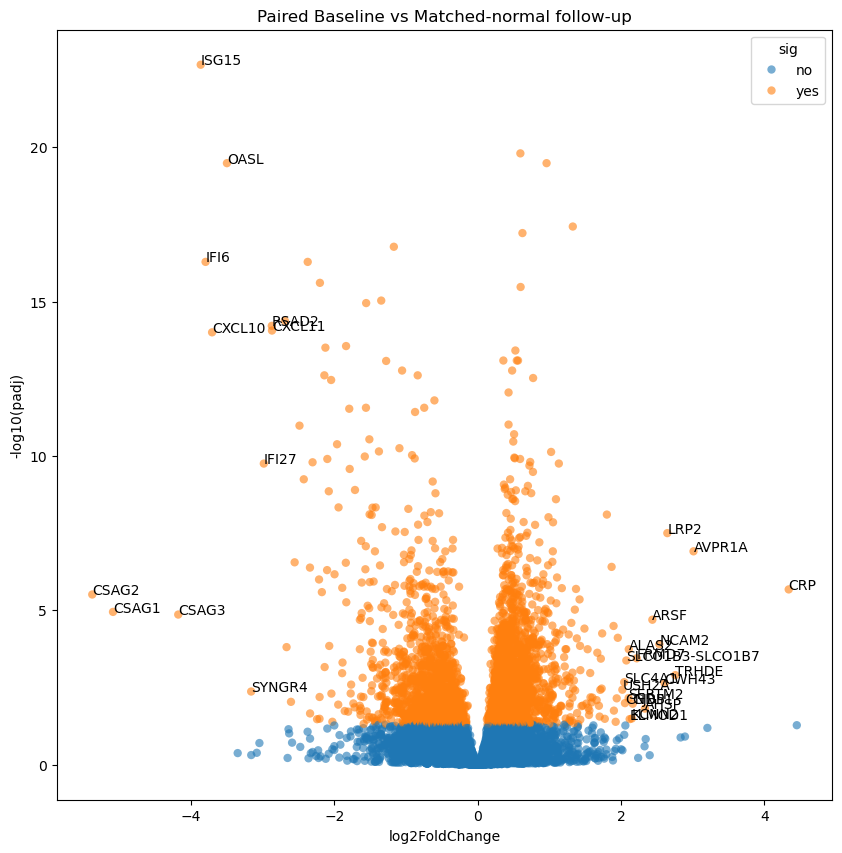

In [48]:
# Volcano (not used in paper)

df_volcano = df_res.copy()
# drop X gene
#df_volcano = df_volcano[df_volcano.Gene != 'CTAG2']

df_volcano['-log10(padj)'] = -np.log10(df_volcano['padj'])
df_volcano['sig'] = np.where(df_volcano['padj'] < 0.05, 'yes', 'no')


fig, ax = plt.subplots(figsize=(10,10))

sns.scatterplot(df_volcano, x=f'log2FoldChange', y='-log10(padj)', hue='sig', hue_order=['no', 'yes'],
               alpha=0.6, linewidth=0, ax=ax)

df_highlight = df_volcano[(df_volcano.sig == 'yes') | (df_volcano.log2FoldChange < -20)].copy()
df_highlight_down = df_highlight[(df_highlight[f'log2FoldChange'] < -2.8) |\
                            (df_highlight['-log10(padj)'] > 20)]

df_highlight_up = df_highlight[df_highlight[f'log2FoldChange'] > 2]


for (label, x, y) in zip(df_highlight_down['Gene_name'], 
                        df_highlight_down[f'log2FoldChange'],
                        df_highlight_down['-log10(padj)']):
    ax.annotate(label, (x, y))

df_highlight_up = df_highlight_up.sort_values(f'log2FoldChange')
for j, (label, x, y) in enumerate(zip(df_highlight_up['Gene_name'], 
                        df_highlight_up[f'log2FoldChange'],
                        df_highlight_up['-log10(padj)'])):
    ax.annotate(label, (x, y))

plt.title('Paired Baseline vs Matched-normal follow-up')
plt.show()
#plt.savefig(f'Volcano_Paired_Baseline_vs_Matched_normal_follow_up.pdf', bbox_inches='tight', dpi=300)